<a href="https://colab.research.google.com/github/Lucas-LSA/TrabalhoAnaliseDeDados/blob/main/TrabalhoDefinitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

In [ ]:
base_path = "/content/drive/MyDrive/"
file_names = [
    "",
    "",
    "",
    "",
    "",
    ""
]


all_dfs = []

standard_columns = [
    'Matéria prima / Produto', 'Tamanhos', 'Descrição', 'Fornecedor',
    'Nota Fiscal', 'Tipo', 'Quantidade', 'Valor Total', 'Data', 'Destino',
    'Solicitante', 'Usuário'
]

for file_name in file_names:
    file_path = base_path + file_name
    try:
        # A leitura dos arquivos tinha que ser feita com o read_html do pandas pois os arquivos eram falsos xls e aparentemente eram do tipo HTML
        tables = pd.read_html(file_path)
        if tables:
            df_single = tables[0]
            print(f"Original columns for {file_name}: {df_single.columns.tolist()}")

            if len(df_single.columns) == len(standard_columns):
                df_single.columns = standard_columns
                all_dfs.append(df_single)
                print(f"Successfully loaded and standardized {file_name}")
            else:
                print(f"Warning: Column count mismatch in {file_name}. Expected {len(standard_columns)}, got {len(df_single.columns)}. Skipping this file to avoid misalignment.")
        else:
            print(f"No tables found in {file_name}")
    except Exception as e:
        print(f"Error loading {file_name}: {e}")


df = pd.concat(all_dfs, ignore_index=True)


display(df.head())

Original columns for Resultado_41622512_05_2026.xls: ['Matéria prima / Produto', 'Tamanhos', 'Descrição', 'Fornecedor', 'Nota fiscal', 'Tipo', 'Quantidade', 'Valor Total', 'Data', 'Destino', 'Solicitante', 'Usuário']
Successfully loaded and standardized Resultado_41622512_05_2026.xls
Original columns for Resultado_41622512_05_20261.xls: ['Matéria prima / Produto', 'Tamanhos', 'Descrição', 'Fornecedor', 'Nota fiscal', 'Tipo', 'Quantidade', 'Valor Total', 'Data', 'Destino', 'Solicitante', 'Usuário']
Successfully loaded and standardized Resultado_41622512_05_20261.xls
Original columns for Resultado_41622512_05_20262.xls: ['Matéria prima / Produto', 'Tamanhos', 'Descrição', 'Fornecedor', 'Nota fiscal', 'Tipo', 'Quantidade', 'Valor Total', 'Data', 'Destino', 'Solicitante', 'Usuário']
Successfully loaded and standardized Resultado_41622512_05_20262.xls
Original columns for Resultado_41622512_05_20263.xls: ['Matéria prima / Produto', 'Tamanhos', 'Descrição', 'Fornecedor', 'Nota fiscal', 'Tipo

,Matéria prima / Produto,Tamanhos,Descrição,Fornecedor,Nota Fiscal,Tipo,Quantidade,Valor Total,Data,Destino,Solicitante,Usuário
0,Tinta MIMAKI - LUS 210,xx,Ciano,...,0,SAÍDA,1.0,"R$ 867,25",02/01/2026 09:40,NaN,Tiago,Tiago
1,Adesivo blackout fosco,1.06x50.00x0.00,"1,06 m",...,0,SAÍDA,1.0,"R$ 357,75",02/01/2026 09:40,NaN,Tiago,Tiago
2,Adesivo blackout fosco,1.06x50.00x0.00,"1,06 m",...,0,SAÍDA,1.0,"R$ 357,75",07/01/2026 09:31,NaN,Gabriel,Gabriel
3,Adesivo fosco,1.52x50.00x0.00,"1,52 m",...,0,SAÍDA,1.0,"R$ 608,00",07/01/2026 09:32,NaN,Gabriel,Gabriel
4,Adesivo fosco,1.06x50.00x0.00,"1,06 m",...,0,SAÍDA,1.0,"R$ 424,00",07/01/2026 17:49,NaN,Gabriel,Gabriel


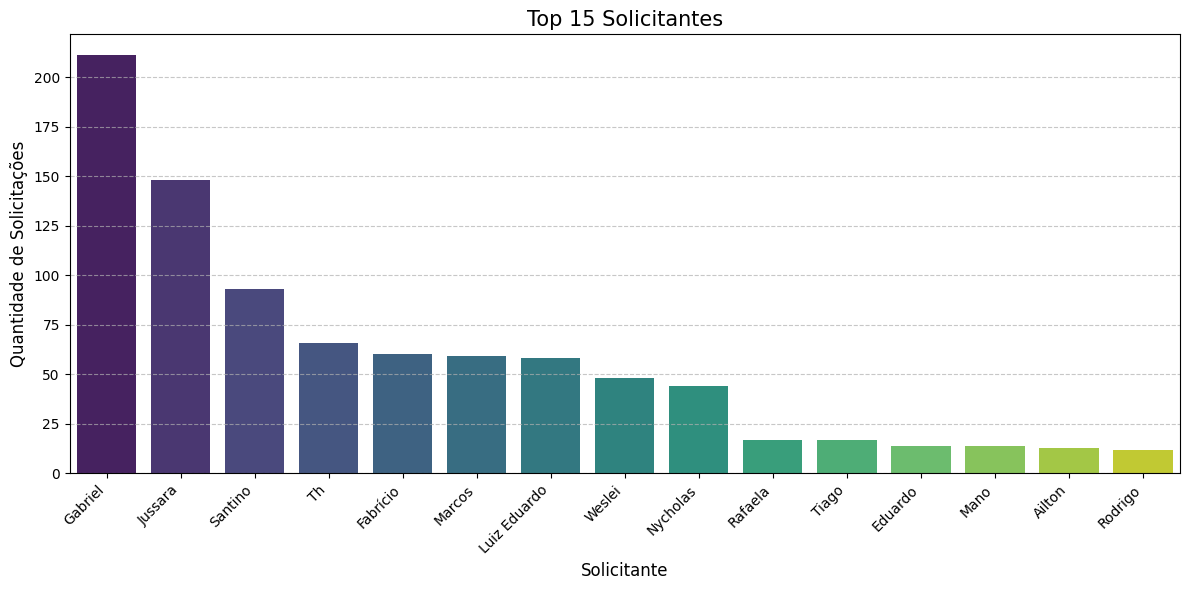

In [ ]:
# 1. Tratamento de dados: Limpeza e Padronização
df_clean = df.dropna(subset=['Solicitante']).copy()
df_clean = df_clean[df_clean['Solicitante'] != '...']

# Padronização de strings
df_clean['Solicitante'] = df_clean['Solicitante'].str.strip().str.title()

# Mapeamento para agrupar variações (Ex: Luiz -> Luiz Eduardo)
mapping = {
    'Luiz': 'Luiz Eduardo',
    'Luiz ': 'Luiz Eduardo',
    'Luiz (Tapume Villa Romana)': 'Luiz Eduardo'
}
df_clean['Solicitante'] = df_clean['Solicitante'].replace(mapping)

# 2. Contagem de solicitações por solicitante após limpeza
solicitacoes_por_pessoa = df_clean['Solicitante'].value_counts().reset_index()
solicitacoes_por_pessoa.columns = ['Solicitante', 'Número de Solicitações']

# 3. Criação do gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=solicitacoes_por_pessoa.head(15), x='Solicitante', y='Número de Solicitações', hue='Solicitante', palette='viridis', legend=False)

plt.title('Top 15 Solicitantes', fontsize=15)
plt.xlabel('Solicitante', fontsize=12)
plt.ylabel('Quantidade de Solicitações', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

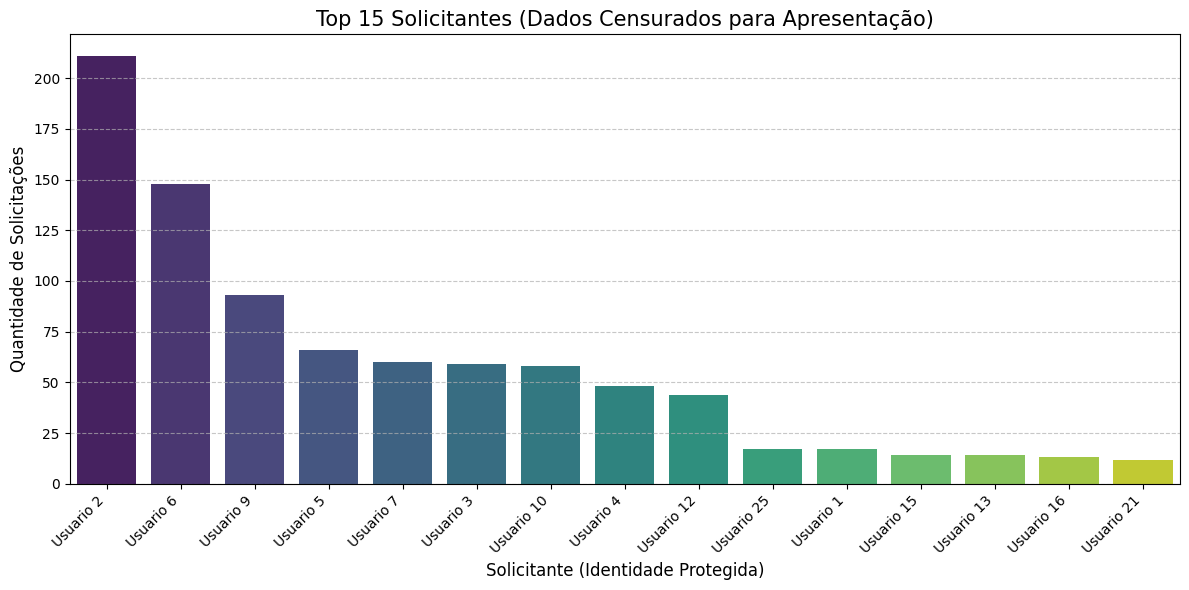


--- Amostra da Censura (De -> Para) ---
Tiago será exibido como: Usuario 1
Gabriel será exibido como: Usuario 2
Marcos será exibido como: Usuario 3
Weslei será exibido como: Usuario 4
Th será exibido como: Usuario 5


In [ ]:
# EXPLICAÇÃO DO ERRO:
# O erro 'NameError: name df is not defined' indica que a tabela principal não está na memória.
# Certifique-se de rodar as células de importação e carregamento de arquivos antes desta.

try:
    # Tenta definir qual dado usar
    if 'df_clean' in locals():
        data_to_use = df_clean.copy()
    elif 'df' in locals():
        print("Aviso: df_clean não encontrado. Usando df original e filtrando solicitantes...")
        data_to_use = df.dropna(subset=['Solicitante']).copy()
    else:
        raise NameError("O DataFrame 'df' não foi detectado. Por favor, execute as células de carregamento de dados (onde os arquivos .xls são lidos) antes desta.")

    # 1. Identificar nomes únicos de solicitantes
    solicitantes_unicos = data_to_use['Solicitante'].unique()

    # 2. Criar um dicionário de mapeamento (Nome Original -> Usuario X)
    mapeamento_censura = {
        nome: f'Usuario {i+1}'
        for i, nome in enumerate(solicitantes_unicos)
    }

    # 3. Aplicar a censura em uma nova coluna
    data_to_use['Solicitante_Censurado'] = data_to_use['Solicitante'].map(mapeamento_censura)

    # 4. Atualizar a contagem para o gráfico
    solicitacoes_por_pessoa_censurado = data_to_use['Solicitante_Censurado'].value_counts().reset_index()
    solicitacoes_por_pessoa_censurado.columns = ['Solicitante', 'Número de Solicitações']

    # 5. Visualização
    plt.figure(figsize=(12, 6))
    sns.barplot(data=solicitacoes_por_pessoa_censurado.head(15), x='Solicitante', y='Número de Solicitações', hue='Solicitante', palette='viridis', legend=False)

    plt.title('Top 15 Solicitantes (Dados Censurados para Apresentação)', fontsize=15)
    plt.xlabel('Solicitante (Identidade Protegida)', fontsize=12)
    plt.ylabel('Quantidade de Solicitações', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print("\n--- Amostra da Censura (De -> Para) ---")
    for original, censurado in list(mapeamento_censura.items())[:5]:
        print(f"{original} será exibido como: {censurado}")

except NameError as e:
    print(f"ERRO DE EXECUÇÃO: {e}")

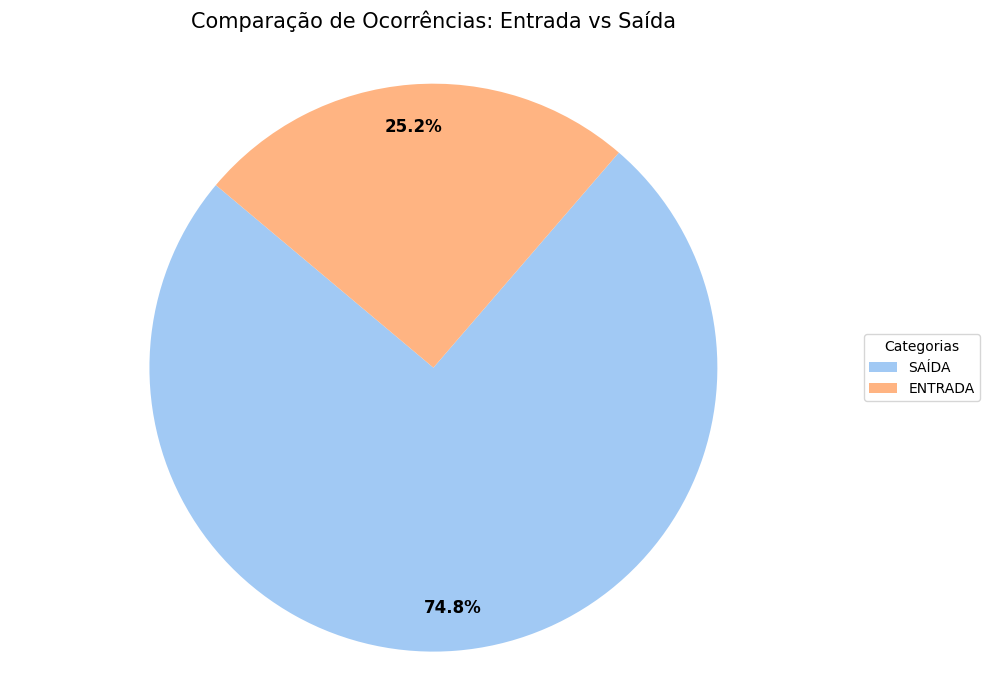

In [ ]:
# 1. Contagem de ocorrências por Tipo (Entrada vs Saída)
tipo_counts = df['Tipo'].value_counts()

# 2. Criação do gráfico de pizza ajustado para evitar sobreposição
plt.figure(figsize=(10, 7))
patches, texts, autotexts = plt.pie(
    tipo_counts,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    pctdistance=0.85  # Move a porcentagem um pouco para fora do centro
)

# Estilizando o texto das porcentagens para ficarem mais visíveis
plt.setp(autotexts, size=12, weight="bold")

# Adicionando uma legenda lateral em vez de labels fixos no gráfico
plt.legend(patches, tipo_counts.index, title="Categorias", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Comparação de Ocorrências: Entrada vs Saída', fontsize=15, pad=20)
plt.axis('equal')

plt.tight_layout()
plt.show()

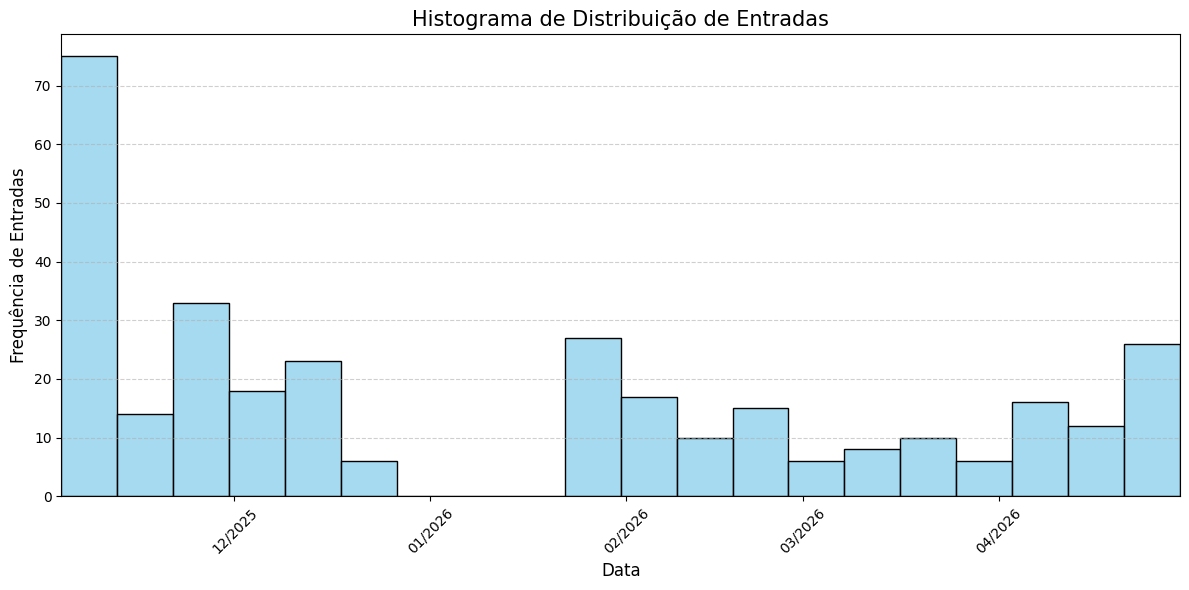

In [ ]:
# 1. Garantir que a coluna de data existe no formato correto
df['Data_dt'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')

# 2. Filtrar apenas entradas e remover datas nulas
df_entradas = df[df['Tipo'] == 'ENTRADA'].dropna(subset=['Data_dt'])

plt.figure(figsize=(12, 6))
# Criando um histograma real baseado na data
sns.histplot(data=df_entradas, x='Data_dt', bins=20, kde=False, color='skyblue')

plt.title('Histograma de Distribuição de Entradas', fontsize=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Frequência de Entradas', fontsize=12)

# Ajustar os limites do eixo X
if not df_entradas.empty:
    plt.xlim(df_entradas['Data_dt'].min(), df_entradas['Data_dt'].max())

# Formatar o eixo X para meses legíveis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

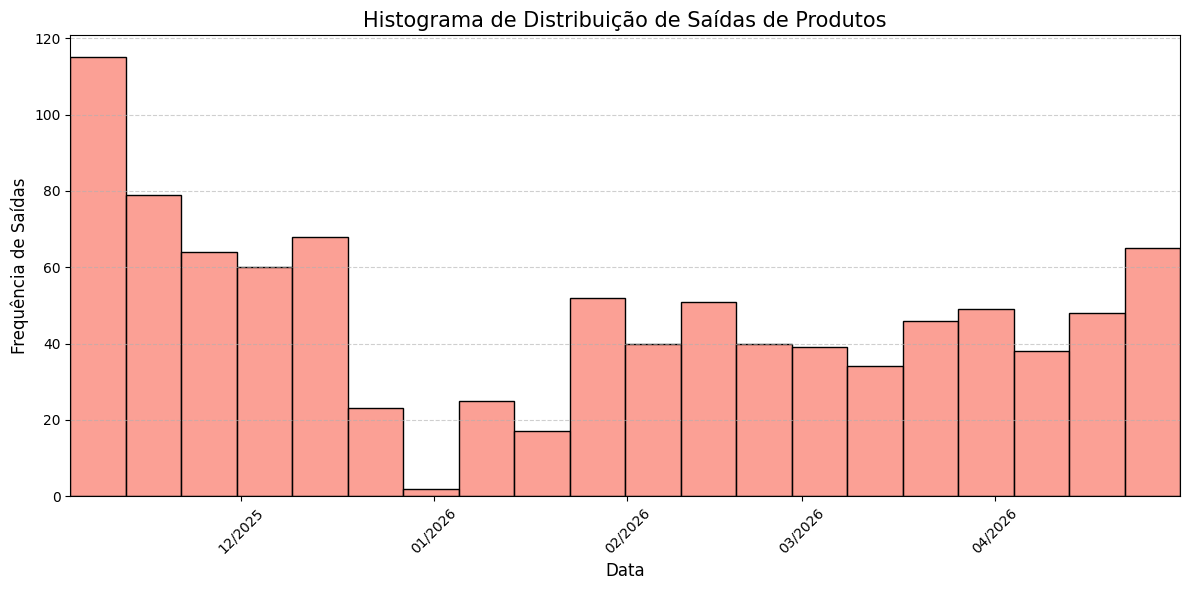

In [ ]:
# Garantir que a coluna de data está no formato datetime (caso ainda não esteja)
df['Data_dt'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')

# Filtrar apenas saídas e remover datas nulas
df_saidas = df[df['Tipo'] == 'SAÍDA'].dropna(subset=['Data_dt'])

plt.figure(figsize=(12, 6))
# Criando o histograma de saídas
sns.histplot(data=df_saidas, x='Data_dt', bins=20, kde=False, color='salmon')

plt.title('Histograma de Distribuição de Saídas de Produtos', fontsize=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Frequência de Saídas', fontsize=12)

# Ajustar os limites para remover períodos vazios
if not df_saidas.empty:
    plt.xlim(df_saidas['Data_dt'].min(), df_saidas['Data_dt'].max())

# Formatar o eixo X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

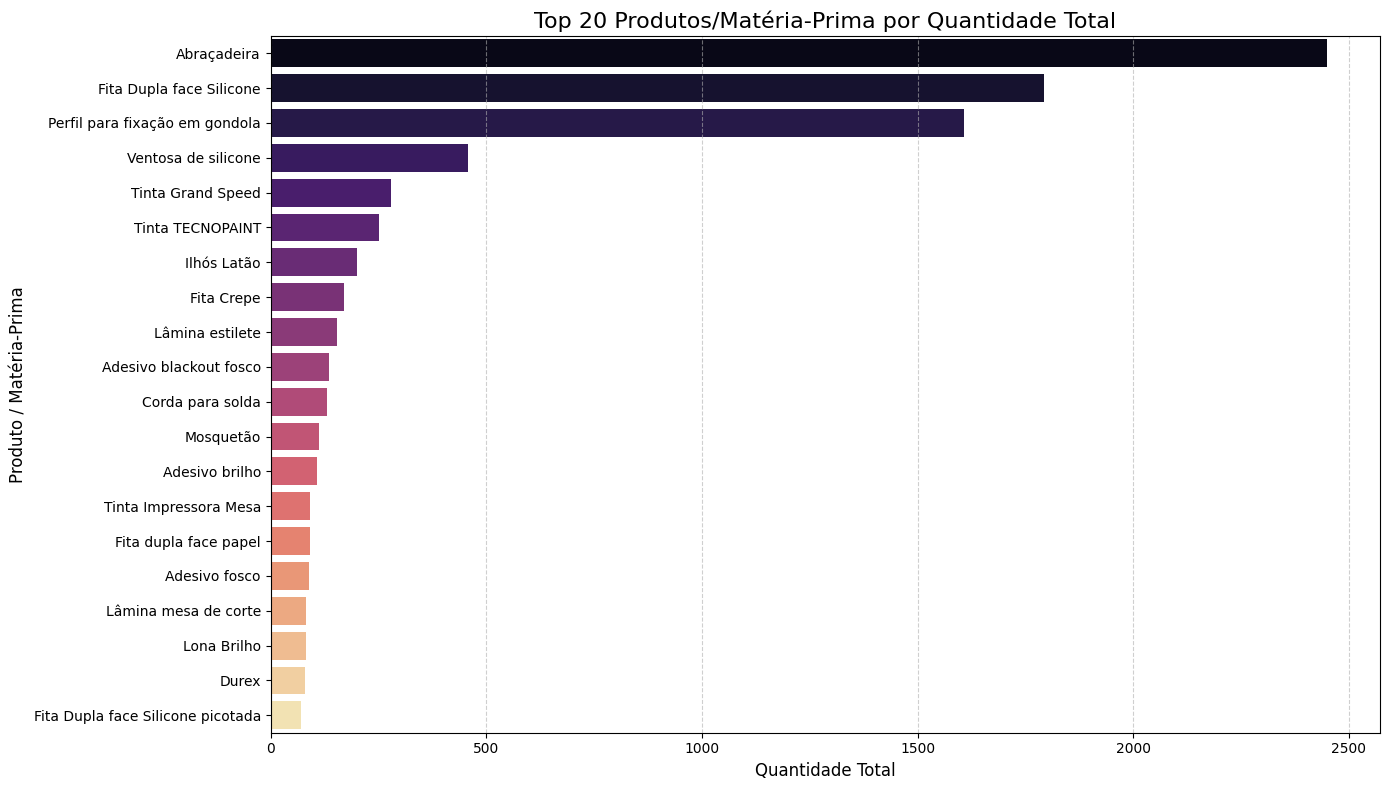

In [ ]:
# 1. Agrupar por produto e somar as quantidades
# Nota: Garantimos que 'Quantidade' é numérica
df['Quantidade'] = pd.to_numeric(df['Quantidade'], errors='coerce').fillna(0)

produtos_qtd = df.groupby('Matéria prima / Produto')['Quantidade'].sum().sort_values(ascending=False).reset_index()

# 2. Criar o gráfico de barras (Top 20 para melhor visualização)
plt.figure(figsize=(14, 8))
sns.barplot(data=produtos_qtd.head(20), x='Quantidade', y='Matéria prima / Produto', hue='Matéria prima / Produto', palette='magma', legend=False)

plt.title('Top 20 Produtos/Matéria-Prima por Quantidade Total', fontsize=16)
plt.xlabel('Quantidade Total', fontsize=12)
plt.ylabel('Produto / Matéria-Prima', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

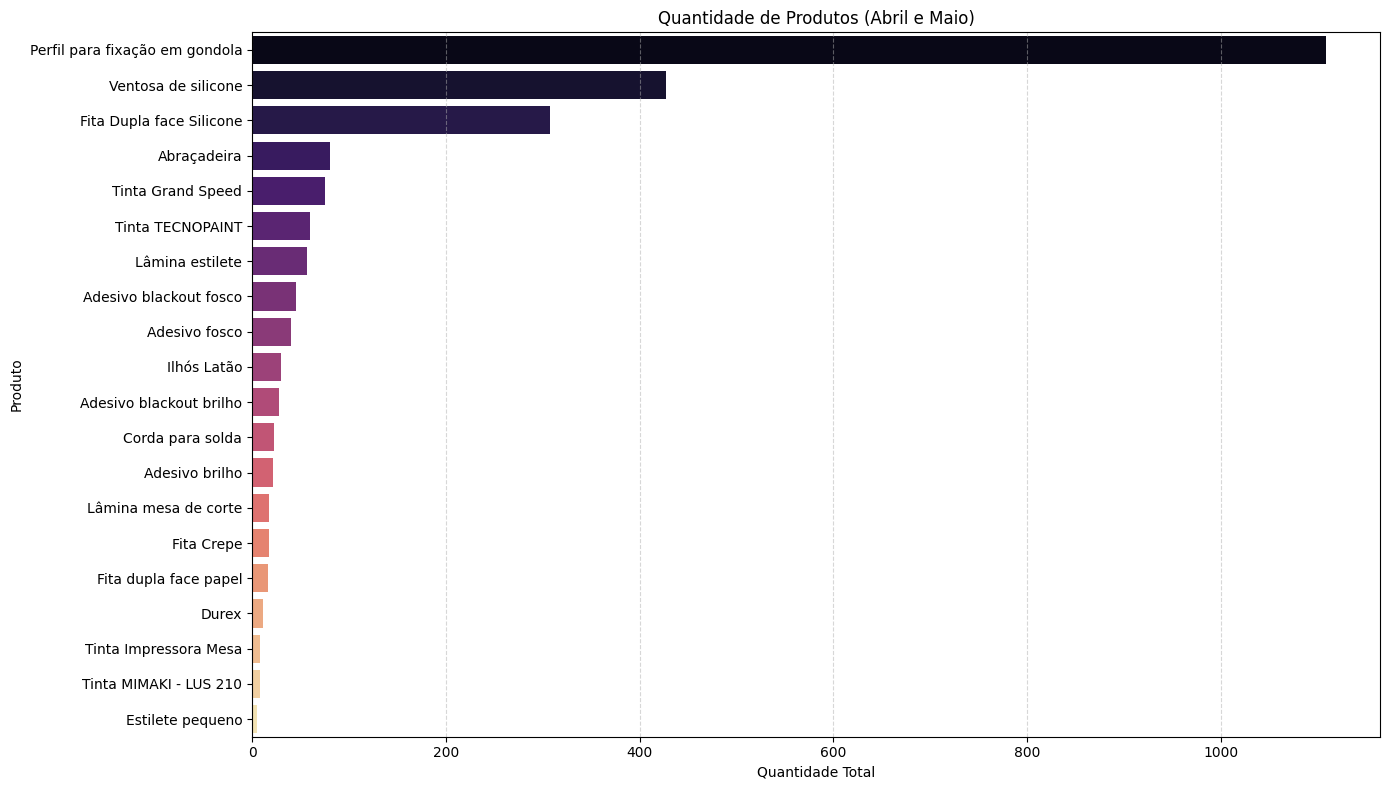

Top 10 itens validados:
          Matéria prima / Produto  Quantidade_limpa
0  Perfil para fixação em gondola            1108.5
1             Ventosa de silicone             427.0
2        Fita Dupla face Silicone             307.0
3                     Abraçadeira              80.0
4               Tinta Grand Speed              75.0
5                Tinta TECNOPAINT              60.0
6                 Lâmina estilete              57.0
7          Adesivo blackout fosco              45.0
8                   Adesivo fosco              40.0
9                     Ilhós Latão              30.0


In [ ]:
# 1. Remover duplicatas exatas
df = df.drop_duplicates().copy()

# 2. Função de limpeza robusta para Quantidade
def limpar_quantidade_final(val):
    if pd.isna(val): return 0.0
    if isinstance(val, (int, float)): return float(val)
    s = str(val).strip().replace(' ', '')
    if ',' in s and '.' in s:
        s = s.replace('.', '').replace(',', '.')
    elif ',' in s:
        s = s.replace(',', '.')
    try:
        return float(s)
    except:
        return 0.0

# Usando .loc para evitar SettingWithCopyWarning
df.loc[:, 'Quantidade_limpa'] = df['Quantidade'].apply(limpar_quantidade_final)
df.loc[:, 'Data_dt'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')

# 3. Filtrar período (Abril e Maio)
mask = (df['Data_dt'].dt.month >= 4) & (df['Data_dt'].dt.month <= 5)
df_periodo = df.loc[mask].copy()

# 4. Agrupar e Somar
resumo_produtos = df_periodo.groupby('Matéria prima / Produto')['Quantidade_limpa'].sum().sort_values(ascending=False).reset_index()

# 5. Visualização
plt.figure(figsize=(14, 8))
sns.barplot(data=resumo_produtos.head(20), x='Quantidade_limpa', y='Matéria prima / Produto', palette='magma', hue='Matéria prima / Produto', legend=False)
plt.title('Quantidade de Produtos (Abril e Maio)')
plt.xlabel('Quantidade Total')
plt.ylabel('Produto')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 10 itens validados:")
print(resumo_produtos.head(10))

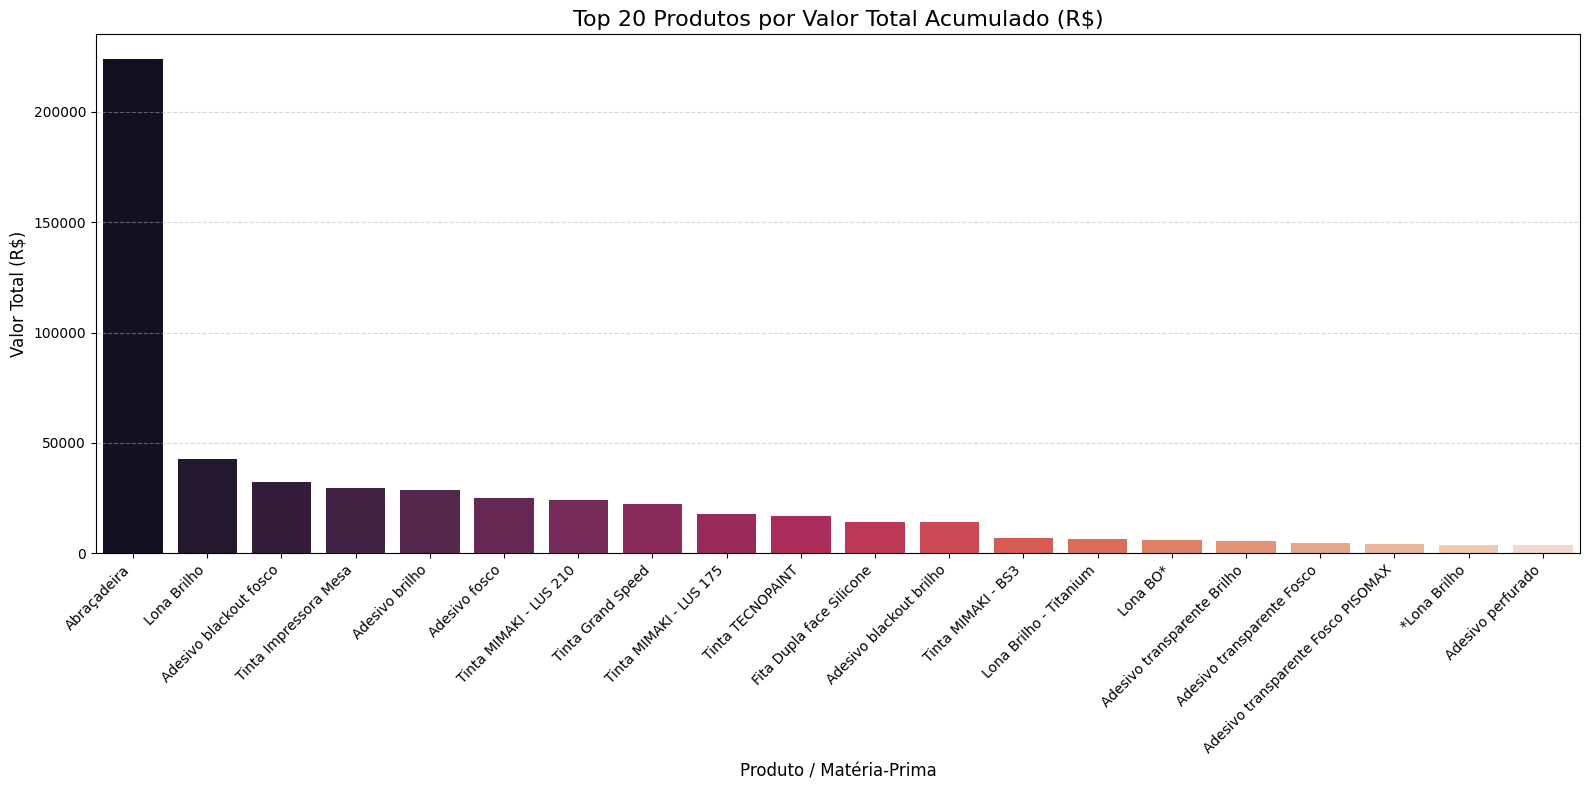

Ranking dos 10 itens de maior valor total:
  Matéria prima / Produto  Valor_Total_limpo
0             Abraçadeira          223996.05
1             Lona Brilho           42512.67
2  Adesivo blackout fosco           32244.81
3   Tinta Impressora Mesa           29562.00
4          Adesivo brilho           28720.00
5           Adesivo fosco           24960.00
6  Tinta MIMAKI - LUS 210           24283.00
7       Tinta Grand Speed           22072.00
8  Tinta MIMAKI - LUS 175           17833.00
9        Tinta TECNOPAINT           16660.00


In [ ]:
# 1. Função para limpar e converter a coluna 'Valor Total'
def limpar_valor_financeiro(val):
    if pd.isna(val): return 0.0
    if isinstance(val, (int, float)): return float(val)
    # Remove 'R$', espaços e pontos de milhar, troca vírgula por ponto
    s = str(val).replace('R$', '').replace(' ', '').replace('.', '').replace(',', '.')
    try:
        return float(s)
    except:
        return 0.0

# Aplicando a limpeza no DataFrame principal
df.loc[:, 'Valor_Total_limpo'] = df['Valor Total'].apply(limpar_valor_financeiro)

# 2. Agrupando por produto e somando o valor total financeiro
produtos_valor = df.groupby('Matéria prima / Produto')['Valor_Total_limpo'].sum().sort_values(ascending=False).reset_index()

# 3. Criando o gráfico com eixos invertidos (Barras Verticais)
plt.figure(figsize=(16, 8))
sns.barplot(data=produtos_valor.head(20), x='Matéria prima / Produto', y='Valor_Total_limpo', hue='Matéria prima / Produto', palette='rocket', legend=False)

plt.title('Top 20 Produtos por Valor Total Acumulado (R$)', fontsize=16)
plt.xlabel('Produto / Matéria-Prima', fontsize=12)
plt.ylabel('Valor Total (R$)', fontsize=12)

# Rotacionar os nomes dos produtos para melhor leitura
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Ranking dos 10 itens de maior valor total:")
print(produtos_valor.head(10))

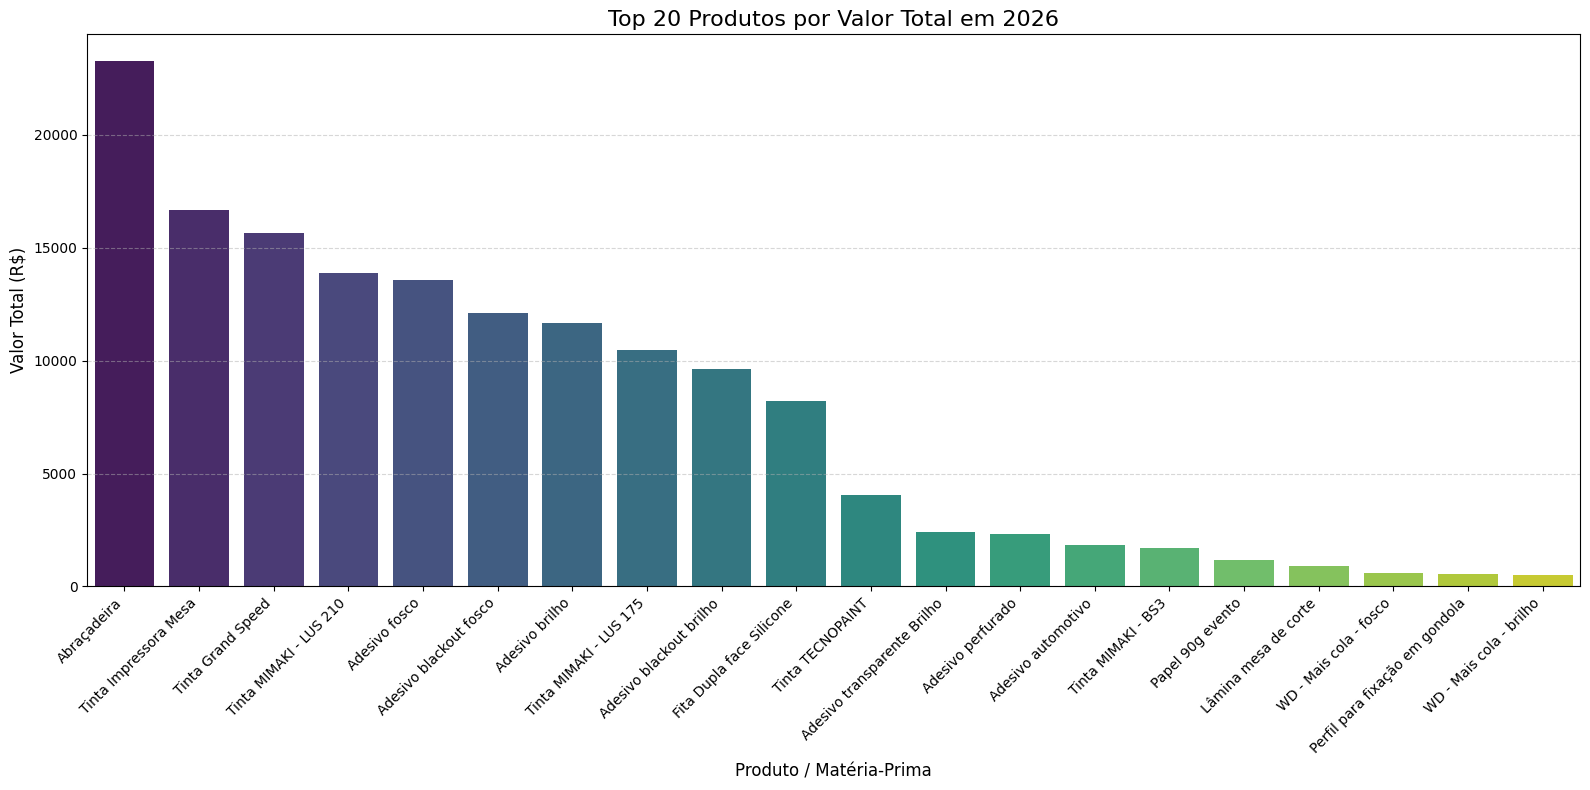

Resumo dos 5 itens mais valiosos em 2026:
  Matéria prima / Produto  Valor_Total_limpo
0             Abraçadeira           23289.12
1   Tinta Impressora Mesa           16676.00
2       Tinta Grand Speed           15664.00
3  Tinta MIMAKI - LUS 210           13876.00
4           Adesivo fosco           13580.00


In [ ]:
# 1. Garantir que a coluna de data e valor estão preparadas
df['Data_dt'] = pd.to_datetime(df['Data'], dayfirst=True, errors='coerce')

# 2. Filtrar dados apenas para o ano de 2026
df_2026 = df[df['Data_dt'].dt.year == 2026].copy()

# 3. Agrupar por produto e somar o valor total financeiro
valor_2026 = df_2026.groupby('Matéria prima / Produto')['Valor_Total_limpo'].sum().sort_values(ascending=False).reset_index()

# 4. Criar o gráfico de barras (Top 20) com eixos invertidos
plt.figure(figsize=(16, 8))
sns.barplot(data=valor_2026.head(20), x='Matéria prima / Produto', y='Valor_Total_limpo', hue='Matéria prima / Produto', palette='viridis', legend=False)

plt.title('Top 20 Produtos por Valor Total em 2026', fontsize=16)
plt.xlabel('Produto / Matéria-Prima', fontsize=12)
plt.ylabel('Valor Total (R$)', fontsize=12)

# Rotacionar labels do eixo X para leitura vertical
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Resumo dos 5 itens mais valiosos em 2026:")
print(valor_2026.head(5))

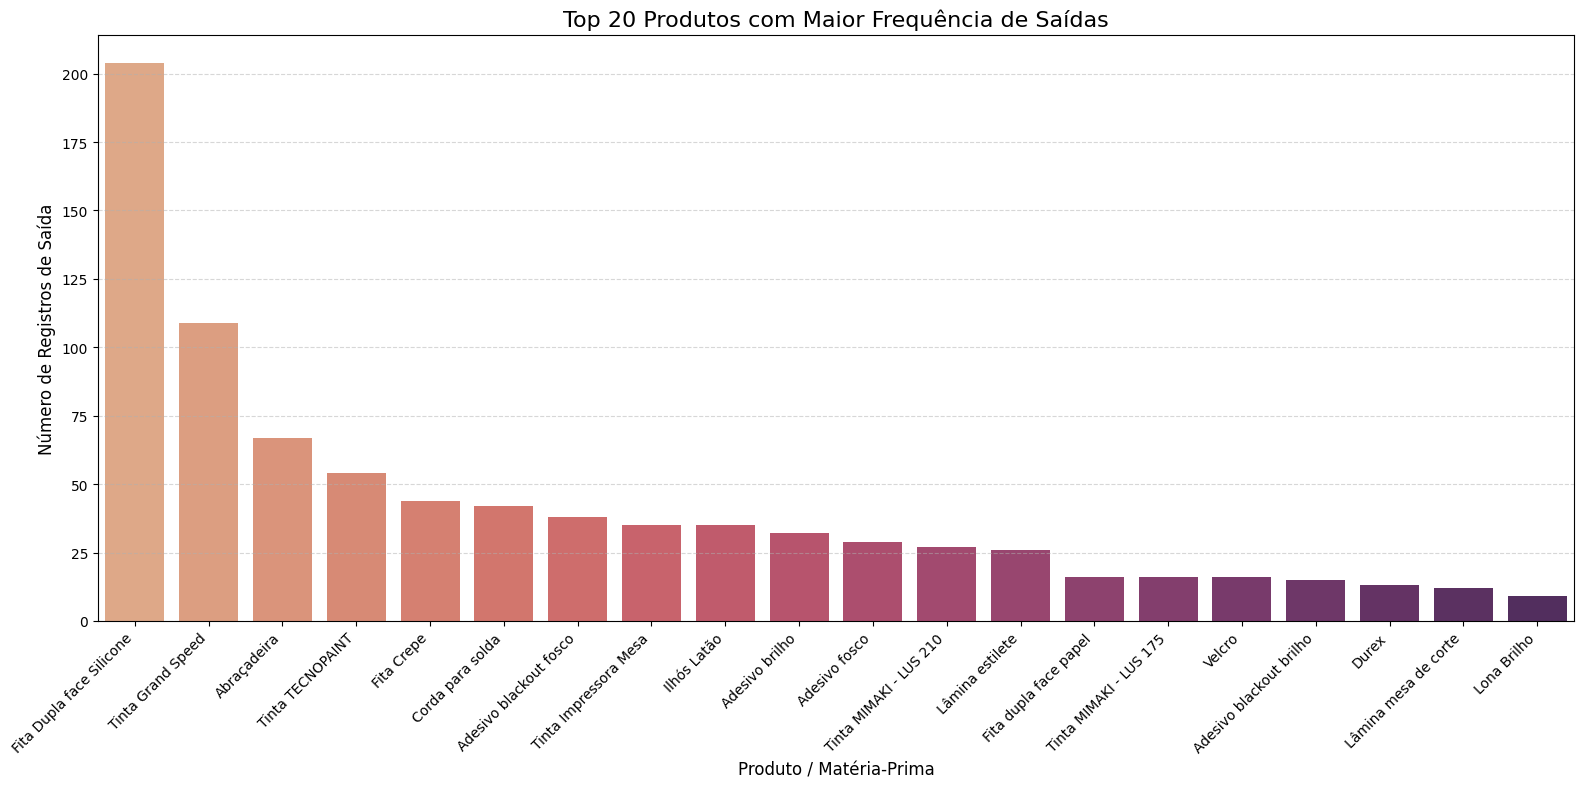

Os 5 produtos que mais geraram registros de saída:
                    Produto  Frequência de Saída
0  Fita Dupla face Silicone                  204
1         Tinta Grand Speed                  109
2               Abraçadeira                   67
3          Tinta TECNOPAINT                   54
4                Fita Crepe                   44


In [ ]:
# 1. Filtrar o DataFrame apenas por registros do tipo 'SAÍDA'
df_saidas_frequencia = df[df['Tipo'] == 'SAÍDA'].copy()

# 2. Contar a frequência de cada produto
ranking_saidas = df_saidas_frequencia['Matéria prima / Produto'].value_counts().reset_index()
ranking_saidas.columns = ['Produto', 'Frequência de Saída']

# 3. Criar a visualização (Top 20) com eixos invertidos
plt.figure(figsize=(16, 8))
sns.barplot(data=ranking_saidas.head(20), x='Produto', y='Frequência de Saída', hue='Produto', palette='flare', legend=False)

plt.title('Top 20 Produtos com Maior Frequência de Saídas', fontsize=16)
plt.xlabel('Produto / Matéria-Prima', fontsize=12)
plt.ylabel('Número de Registros de Saída', fontsize=12)

# Rotacionar os nomes dos produtos para melhor leitura
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Os 5 produtos que mais geraram registros de saída:")
print(ranking_saidas.head(5))

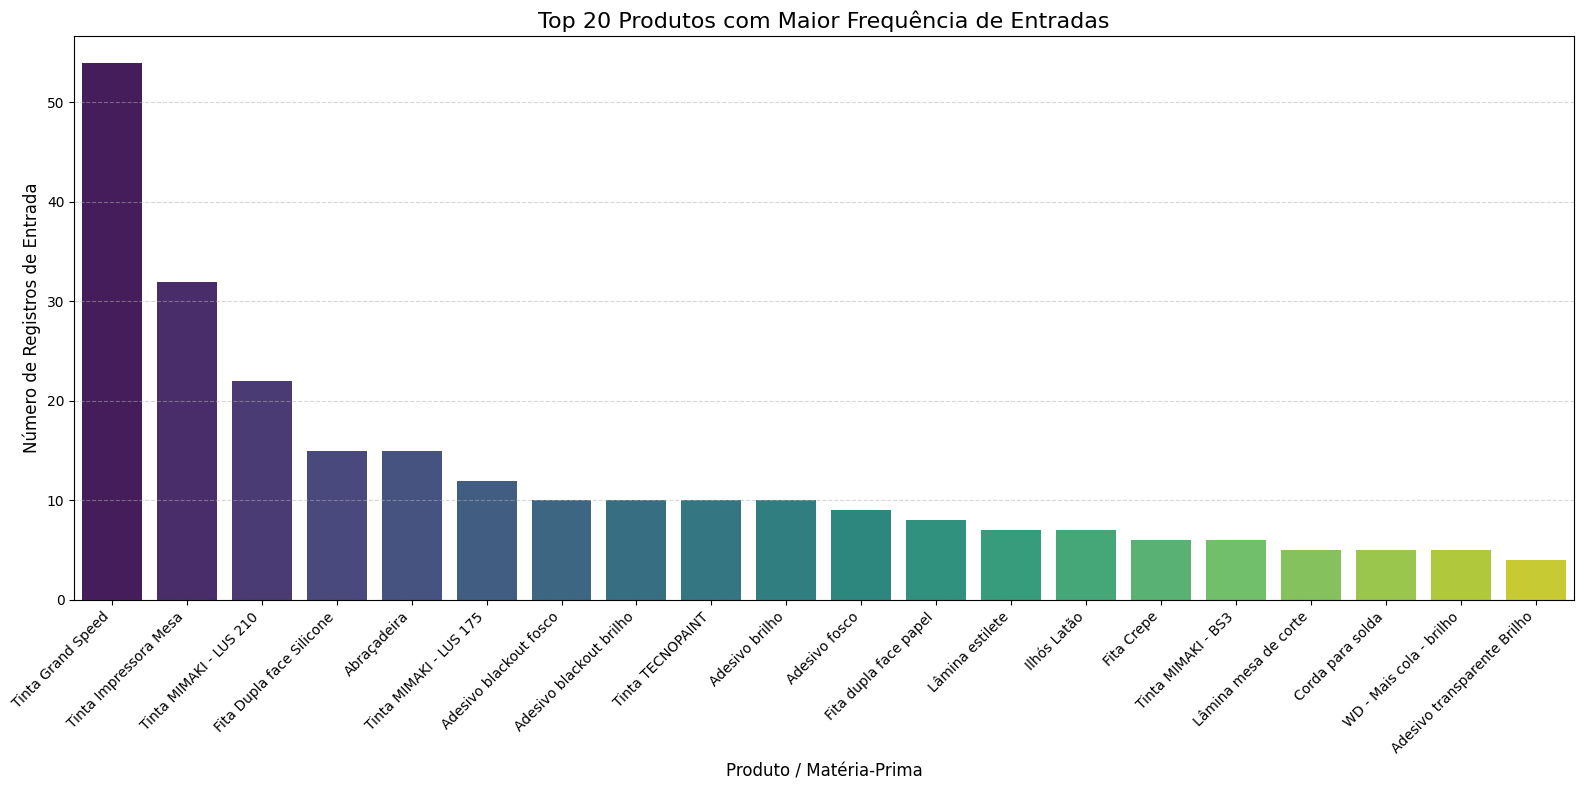

Os 5 produtos que mais geraram registros de entrada:
                    Produto  Frequência de Entrada
0         Tinta Grand Speed                     54
1     Tinta Impressora Mesa                     32
2    Tinta MIMAKI - LUS 210                     22
3  Fita Dupla face Silicone                     15
4               Abraçadeira                     15


In [ ]:
# 1. Filtrar o DataFrame apenas por registros do tipo 'ENTRADA'
df_entradas_frequencia = df[df['Tipo'] == 'ENTRADA'].copy()

# 2. Contar a frequência de cada produto
ranking_entradas = df_entradas_frequencia['Matéria prima / Produto'].value_counts().reset_index()
ranking_entradas.columns = ['Produto', 'Frequência de Entrada']

# 3. Criar a visualização (Top 20)
plt.figure(figsize=(16, 8))
sns.barplot(data=ranking_entradas.head(20), x='Produto', y='Frequência de Entrada', hue='Produto', palette='viridis', legend=False)

plt.title('Top 20 Produtos com Maior Frequência de Entradas', fontsize=16)
plt.xlabel('Produto / Matéria-Prima', fontsize=12)
plt.ylabel('Número de Registros de Entrada', fontsize=12)

# Rotacionar os nomes dos produtos para melhor leitura
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Os 5 produtos que mais geraram registros de entrada:")
print(ranking_entradas.head(5))